In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results__.html
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__notebook__.ipynb
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__output__.json
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/custom.css
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___38_1.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___40_0.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___31_0.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___36_0.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___30_0.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___44_0.png
/kaggle/input/notebooks/omniayasser2512/hotel-booking-demand/__results___files/__results___29

In [7]:
import os
import pandas as pd
import numpy as np

# 1. Search for any CSV file related to hotel bookings in ../input/
file_path = None
if os.path.exists('../input/'):
    for root, dirs, files in os.walk('../input/'):
        for file in files:
            if file.lower().endswith('.csv') and 'hotel' in file.lower():
                file_path = os.path.join(root, file)
                break

# 2. Check if file was found before reading
if file_path is None:
    print("❌ ERROR: Could not find 'hotel_bookings.csv' inside ../input/")
    print("\nFolders currently inside ../input/:")
    print(os.listdir('../input/') if os.path.exists('../input/') else "No ../input/ folder exists.")
    print("\n👉 Please click '+ Add Input' in the right sidebar and attach the 'Hotel Booking Demand' dataset.")
else:
    print(f"✅ File found at: {file_path}")
    df = pd.read_csv(file_path)
    print(f"Raw Dataset Loaded Successfully! Initial Rows: {len(df):,}")

    # 3. Data Cleaning for Hospitality Analysis
    df = df[(df['adults'] + df['children'] + df['babies']) > 0].copy()
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df = df[df['total_nights'] > 0]
    df['booking_revenue'] = df['adr'] * df['total_nights']

    # Estimate Commission Rates per Channel
    commission_map = {
        'Direct': 0.00,
        'Corporate': 0.05,
        'TA/TO': 0.18,
        'Offline TA/TO': 0.12,
        'Complementary': 0.00
    }
    df['commission_rate'] = df['market_segment'].map(commission_map).fillna(0.15)
    df['net_booking_revenue'] = np.where(
        df['is_canceled'] == 0, 
        df['booking_revenue'] * (1 - df['commission_rate']), 
        0
    )

    # Lead Time Buckets
    bins = [-1, 7, 30, 90, 180, 730]
    labels = ['0-7 Days (Last Minute)', '8-30 Days', '31-90 Days', '91-180 Days', '180+ Days (Far Out)']
    df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

    print("Data Cleaning & Feature Engineering Complete!")
    display(df[['hotel', 'market_segment', 'adr', 'total_nights', 'booking_revenue', 'net_booking_revenue']].head())

✅ File found at: ../input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv
Raw Dataset Loaded Successfully! Initial Rows: 119,390
Data Cleaning & Feature Engineering Complete!


,hotel,market_segment,adr,total_nights,booking_revenue,net_booking_revenue
2,Resort Hotel,Direct,75.0,1,75.0,75.00
3,Resort Hotel,Corporate,75.0,1,75.0,71.25
4,Resort Hotel,Online TA,98.0,2,196.0,166.60
5,Resort Hotel,Online TA,98.0,2,196.0,166.60
6,Resort Hotel,Direct,107.0,2,214.0,214.00


In [8]:
# 1. Remove invalid bookings (0 guests) and 0-night stays
df = df[(df['adults'] + df['children'] + df['babies']) > 0].copy()
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df = df[df['total_nights'] > 0]

# 2. Calculate Gross Booking Revenue
df['booking_revenue'] = df['adr'] * df['total_nights']

# 3. Estimate Commission Rates per Channel (Industry Standards)
commission_map = {
    'Direct': 0.00,
    'Corporate': 0.05,
    'TA/TO': 0.18,       # OTAs like Booking.com/Expedia
    'Offline TA/TO': 0.12,
    'Complementary': 0.00
}
df['commission_rate'] = df['market_segment'].map(commission_map).fillna(0.15)

# 4. Calculate Net Revenue (Post-Commission) for non-canceled stays
df['net_booking_revenue'] = np.where(
    df['is_canceled'] == 0, 
    df['booking_revenue'] * (1 - df['commission_rate']), 
    0
)

# 5. Create Lead Time Buckets for Revenue Strategy
bins = [-1, 7, 30, 90, 180, 730]
labels = ['0-7 Days (Last Minute)', '8-30 Days', '31-90 Days', '91-180 Days', '180+ Days (Far Out)']
df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

print("Data Cleaning & Feature Engineering Complete!")
df[['hotel', 'market_segment', 'adr', 'total_nights', 'booking_revenue', 'net_booking_revenue']].head()

Data Cleaning & Feature Engineering Complete!


,hotel,market_segment,adr,total_nights,booking_revenue,net_booking_revenue
2,Resort Hotel,Direct,75.0,1,75.0,75.00
3,Resort Hotel,Corporate,75.0,1,75.0,71.25
4,Resort Hotel,Online TA,98.0,2,196.0,166.60
5,Resort Hotel,Online TA,98.0,2,196.0,166.60
6,Resort Hotel,Direct,107.0,2,214.0,214.00


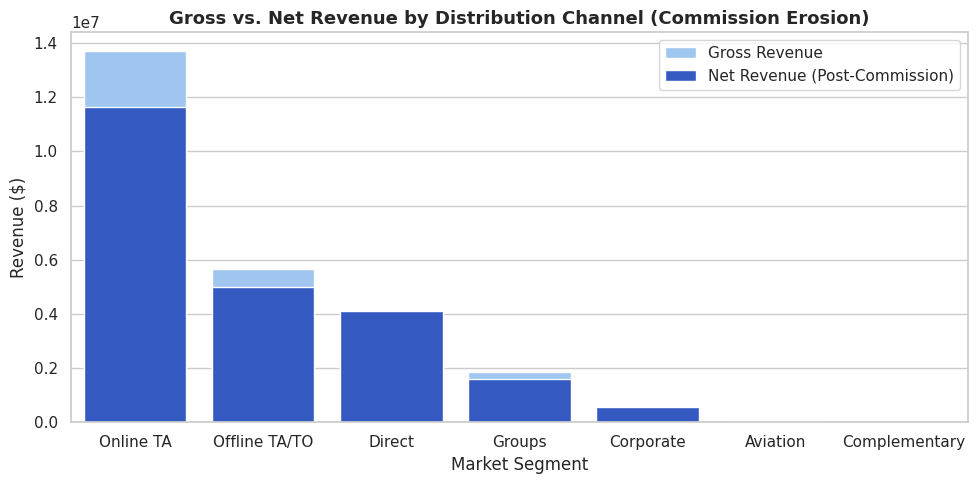

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Aggregate Non-Canceled Revenue by Market Segment
channel_summary = df[df['is_canceled'] == 0].groupby('market_segment').agg(
    total_bookings=('hotel', 'count'),
    avg_adr=('adr', 'mean'),
    total_gross_revenue=('booking_revenue', 'sum'),
    total_net_revenue=('net_booking_revenue', 'sum')
).reset_index()

channel_summary = channel_summary.sort_values(by='total_gross_revenue', ascending=False)

# Bar Chart: Gross vs. Net Revenue
plt.figure(figsize=(10, 5))
sns.barplot(data=channel_summary, x='market_segment', y='total_gross_revenue', color='#93c5fd', label='Gross Revenue')
sns.barplot(data=channel_summary, x='market_segment', y='total_net_revenue', color='#1d4ed8', label='Net Revenue (Post-Commission)')

plt.title('Gross vs. Net Revenue by Distribution Channel (Commission Erosion)', fontsize=13, fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

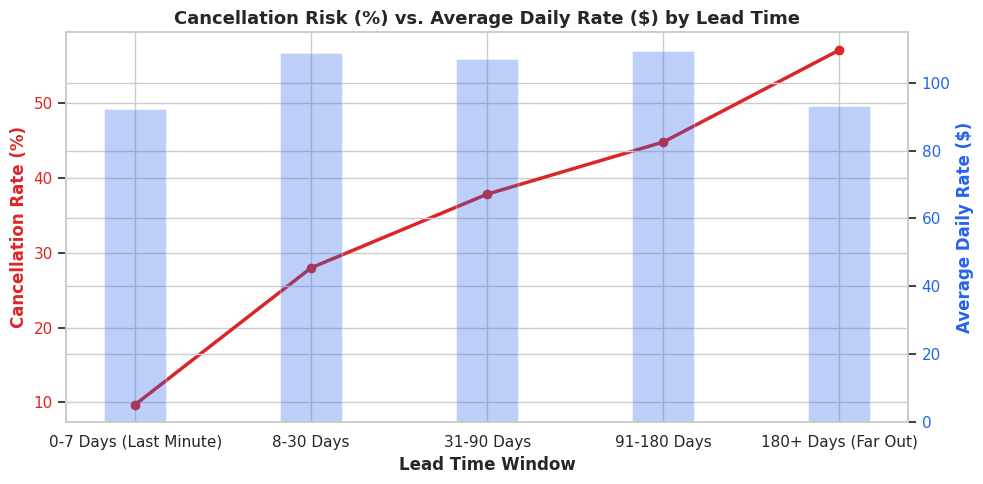

In [10]:
# Group by Lead Time Buckets
lead_time_summary = df.groupby('lead_time_bucket', observed=False).agg(
    total_bookings=('is_canceled', 'count'),
    cancellations=('is_canceled', 'sum'),
    avg_adr=('adr', 'mean')
).reset_index()

lead_time_summary['cancellation_rate'] = (lead_time_summary['cancellations'] / lead_time_summary['total_bookings']) * 100

# Dual-Axis Plot: Cancellation Rate vs. ADR
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Cancellation Rate
color = '#dc2626'
ax1.set_xlabel('Lead Time Window', fontweight='bold')
ax1.set_ylabel('Cancellation Rate (%)', color=color, fontweight='bold')
ax1.plot(lead_time_summary['lead_time_bucket'], lead_time_summary['cancellation_rate'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)

# Secondary Axis: ADR
ax2 = ax1.twinx()  
color = '#2563eb'
ax2.set_ylabel('Average Daily Rate ($)', color=color, fontweight='bold')
ax2.bar(lead_time_summary['lead_time_bucket'], lead_time_summary['avg_adr'], color=color, alpha=0.3, width=0.35)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Cancellation Risk (%) vs. Average Daily Rate ($) by Lead Time', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

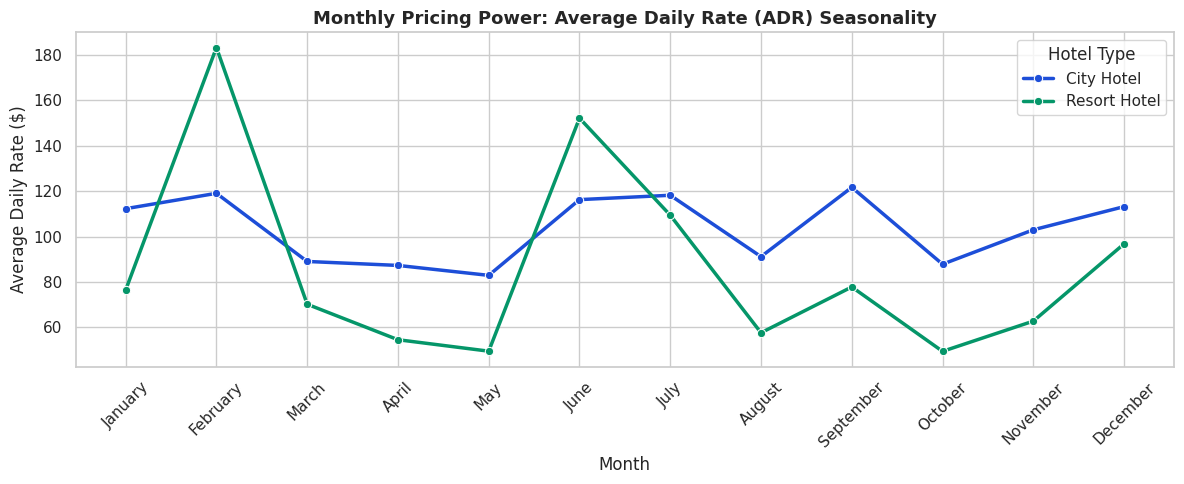

In [11]:
# Define chronological month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Aggregate monthly figures for non-canceled bookings
monthly_rev = df[df['is_canceled'] == 0].groupby(['arrival_date_month', 'hotel']).agg(
    avg_adr=('adr', 'mean'),
    total_revenue=('net_booking_revenue', 'sum')
).reset_index()

# Plot Monthly ADR Trends
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_rev, 
    x='arrival_date_month', 
    y='avg_adr', 
    hue='hotel', 
    marker='o', 
    linewidth=2.5,
    palette=['#1d4ed8', '#059669']
)

plt.xticks(ticks=range(12), labels=month_order, rotation=45)
plt.title('Monthly Pricing Power: Average Daily Rate (ADR) Seasonality', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate ($)')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

In [12]:
# 1. High-Level Financial Metrics
total_gross_rev = df[df['is_canceled'] == 0]['booking_revenue'].sum()
total_net_rev = df['net_booking_revenue'].sum()
total_commission_loss = total_gross_rev - total_net_rev
overall_cancel_rate = (df['is_canceled'].sum() / len(df)) * 100

print("=" * 55)
print("       EXECUTIVE REVENUE PERFORMANCE SUMMARY       ")
print("=" * 55)
print(f"Gross Room Revenue (Non-Canceled): ${total_gross_rev:,.2f}")
print(f"Net Room Revenue (Post-Commission): ${total_net_rev:,.2f}")
print(f"Estimated OTA Commission Loss:     ${total_commission_loss:,.2f} ({(total_commission_loss/total_gross_rev)*100:.1f}% leakage)")
print(f"Overall Booking Cancellation Rate: {overall_cancel_rate:.2f}%")
print("=" * 55)

# 2. Export clean CSV to Kaggle output
df.to_csv('hotel_revenue_cleaned.csv', index=False)
print("\n✅ Dataset successfully exported as 'hotel_revenue_cleaned.csv'.")

       EXECUTIVE REVENUE PERFORMANCE SUMMARY       
Gross Room Revenue (Non-Canceled): $25,986,912.23
Net Room Revenue (Post-Commission): $22,931,841.61
Estimated OTA Commission Loss:     $3,055,070.62 (11.8% leakage)
Overall Booking Cancellation Rate: 37.26%

✅ Dataset successfully exported as 'hotel_revenue_cleaned.csv'.
